# Boundary variance inflation in Gaussian processes

A short, runnable tour of the paper's central observation, built from the same `src/` code that produces the figures. Everything here runs in a few seconds on CPU.

The story in three steps:

1. **The mechanism.** A GP's posterior variance rises near a domain boundary, because the kernel's correlation neighbourhood is cut off by the wall.
2. **The consequence.** Variance-driven acquisitions inherit this: their argmax is pulled to the boundary, regardless of the observed function values.
3. **The diagnostic.** Over many random designs, the argmax concentrates near the boundary for VM, while EPIG sits further inside.

The paper also tests a Neumann (mirror-image) kernel as a *partial* correction. Its effect grows with dimension and needs the full volume-corrected diagnostic to see clearly, so we leave it to the reproduction scripts (Fig 8, `figures/plot_neumann.py`) rather than this short 2D tour.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.kernels import matern52_isotropic
from src.gp import posterior_variance
from src.acquisitions import compute_eig, compute_epig
from src.plot_style import apply_style, COLORS

apply_style()
torch.set_default_dtype(torch.float64)

## 1. The mechanism: variance inflates at the boundary

Five evenly spaced training points on $[0,1]$ under a Matérn-5/2 kernel. The posterior variance dips at the training points and rises between them, but near $x=0$ and $x=1$ it stays high: the wall truncates the kernel's correlation neighbourhood, so a boundary point is informed by fewer in-domain neighbours.

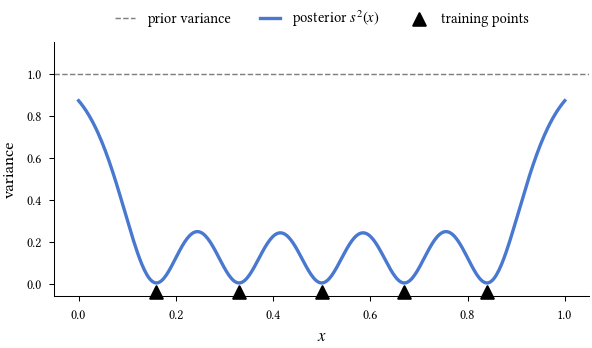

In [2]:
ls, sigma2 = 0.12, 0.003
x_train = torch.tensor([0.16, 0.33, 0.50, 0.67, 0.84]).reshape(-1, 1)
x_grid = torch.linspace(0, 1, 400).reshape(-1, 1)
s2 = posterior_variance(x_grid, x_train, matern52_isotropic, ls, sigma2)

fig, ax = plt.subplots(figsize=(4.6, 2.2))
ax.axhline(1.0, color='gray', ls='--', lw=0.7, label='prior variance')
ax.plot(x_grid.ravel(), s2, color=COLORS['blue'], lw=1.6, label=r'posterior $s^2(x)$')
ax.scatter(x_train.ravel(), torch.full((5,), -0.04), marker='^', color='k', clip_on=False, label='training points')
ax.set_xlabel('$x$'); ax.set_ylabel('variance'); ax.set_ylim(-0.06, 1.15)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=3, fontsize=7)
plt.show()

## 2. The consequence: VM's argmax goes to a corner

Variance maximization (VM) picks the point of highest posterior variance. In 2D, with a random design, that point sits at a corner of the square: the place with the least in-domain correlated volume. This is driven purely by geometry; no function values enter.

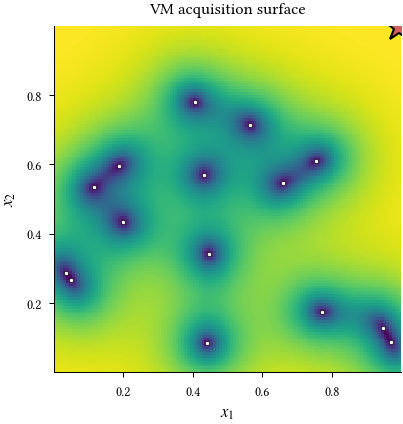

VM argmax: [0.995, 0.995] -> a corner


In [3]:
D, ls = 2, 0.2
g = torch.linspace(0.005, 0.995, 120)
xx, yy = torch.meshgrid(g, g, indexing='ij')
X_grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=-1)

gen = torch.Generator().manual_seed(3)
X_train = torch.rand(15, D, generator=gen)
vm = compute_eig(X_grid, X_train, torch.tensor(ls), matern52_isotropic, sigma2)
argmax = X_grid[vm.argmax()]

fig, ax = plt.subplots(figsize=(3.0, 3.0))
ax.pcolormesh(xx, yy, (vm / vm.max()).reshape(120, 120), cmap='viridis', shading='auto')
ax.plot(X_train[:, 0], X_train[:, 1], 'w.', ms=4, markeredgecolor='k', markeredgewidth=0.3)
ax.plot(*argmax, marker='*', color=COLORS['red'], ms=14, markeredgecolor='k')
ax.set_title('VM acquisition surface'); ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.set_aspect('equal')
plt.show()
print('VM argmax:', argmax.tolist(), '-> a corner')

## 3. The diagnostic: where does the argmax land, on average?

Repeat over many random designs and record the argmax's distance to the boundary $d_\partial = \min_i \min(x_i, 1-x_i)$. VM piles up at $d_\partial \approx 0$ (the boundary); EPIG, which rewards predictive information about the whole domain, sits at an interior shell. This is the function-free diagnostic the paper builds on (here in miniature: a few hundred designs on a coarse grid).

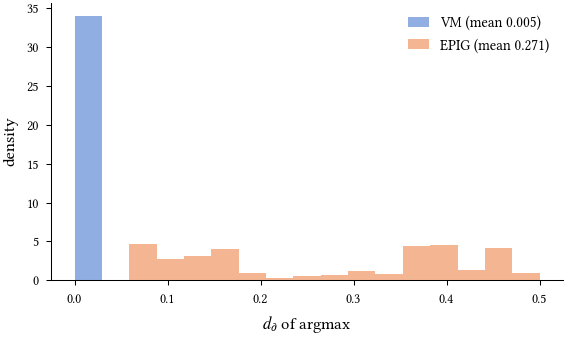

In [4]:
def boundary_distance(X):
    return torch.minimum(X, 1 - X).min(dim=-1).values

d_bnd_grid = boundary_distance(X_grid)
X_int = torch.rand(512, D, generator=torch.Generator().manual_seed(99))
n_designs = 300
vm_d, epig_d = [], []
for s in range(n_designs):
    gen = torch.Generator().manual_seed(1000 + s)
    Xt = torch.rand(15, D, generator=gen)
    vm_s = compute_eig(X_grid, Xt, torch.tensor(ls), matern52_isotropic, sigma2)
    epig_s = compute_epig(X_grid, X_int, Xt, torch.tensor(ls), matern52_isotropic, sigma2)
    vm_d.append(float(d_bnd_grid[vm_s.argmax()]))
    epig_d.append(float(d_bnd_grid[epig_s.argmax()]))

fig, ax = plt.subplots(figsize=(4.4, 2.4))
bins = np.linspace(0, 0.5, 18)
ax.hist(vm_d, bins=bins, density=True, alpha=0.6, color=COLORS['blue'], label=f'VM (mean {np.mean(vm_d):.3f})')
ax.hist(epig_d, bins=bins, density=True, alpha=0.6, color=COLORS['orange'], label=f'EPIG (mean {np.mean(epig_d):.3f})')
ax.set_xlabel(r'$d_\partial$ of argmax'); ax.set_ylabel('density'); ax.legend(fontsize=7)
plt.show()

## Next steps

The figures in the paper are the full-scale versions of what you just saw, computed across dimensions and lengthscales with the volume-corrected diagnostic. To regenerate them:

```bash
python experiments/compute_sweep.py        # then: python figures/plot_boundary_profiles.py   (Fig 2)
python experiments/compute_2d_surfaces.py  # then: python figures/plot_2d_surfaces.py          (Fig 1)
python figures/plot_neumann.py             # Fig 8: the Neumann correction, strengthening with D
```

See the README for the full figure-by-figure reproduction table.